<a href="https://colab.research.google.com/github/VijayReddy-07/TASK-1-STUDENT-PERFORMANCE-ANALYSIS/blob/main/student_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ==========================
# TASK 1 - STUDENT PERFORMANCE ANALYSIS
# ==========================

In [5]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --------------------------
# 1. LOAD DATASET
# --------------------------

In [6]:
# Upload student-mat.csv to Colab first
df = pd.read_csv('student-mat.csv', sep=';')

print("Dataset Loaded Successfully!")
print(df.head())

Dataset Loaded Successfully!
  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        6   5   6   6  
1      5        3      3     1     1      3        4   5   5   6  
2      4        3      2     2     3      3       10   7   8  10  
3      3        2      2     1     1      5        2  15  14  15  
4      4        3      2     1     2      5        4   6  10  10  

[5 rows x 33 columns]


# --------------------------
# 2. EXPLORE DATA
# --------------------------

In [7]:
print("\nDataset Shape:")
print(df.shape)


Dataset Shape:
(395, 33)


In [8]:
print("\nColumn Names:")
print(df.columns)


Column Names:
Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')


In [9]:
print("\nData Types:")
print(df.dtypes)


Data Types:
school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences       int64
G1             int64
G2             int64
G3             int64
dtype: object


In [10]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64


In [11]:
print("\nDuplicate Rows:")
print(df.duplicated().sum())


Duplicate Rows:
0


In [12]:
# Remove duplicates
df = df.drop_duplicates()

In [13]:
print("\nShape After Removing Duplicates:")
print(df.shape)


Shape After Removing Duplicates:
(395, 33)


# --------------------------
# 3. ANALYSIS QUESTIONS
# --------------------------

In [14]:
# Average Final Grade (G3)
avg_grade = df['G3'].mean()

print("\nAverage Final Grade (G3):")
print(round(avg_grade, 2))


Average Final Grade (G3):
10.42


In [15]:
# Students scoring above 15
above_15 = df[df['G3'] > 15].shape[0]

print("\nStudents Scoring Above 15:")
print(above_15)



Students Scoring Above 15:
40


In [16]:
# Correlation between Study Time and G3
correlation = df['studytime'].corr(df['G3'])

print("\nCorrelation Between Study Time and G3:")
print(round(correlation, 2))



Correlation Between Study Time and G3:
0.1


In [17]:
# Gender-wise average score
gender_performance = df.groupby('sex')['G3'].mean()

print("\nAverage Score by Gender:")
print(gender_performance)



Average Score by Gender:
sex
F     9.966346
M    10.914439
Name: G3, dtype: float64


In [18]:
# Better Performing Gender
best_gender = gender_performance.idxmax()

print("\nBetter Performing Gender:")
print(best_gender)


Better Performing Gender:
M


# --------------------------
# 4. VISUALIZATIONS
# --------------------------

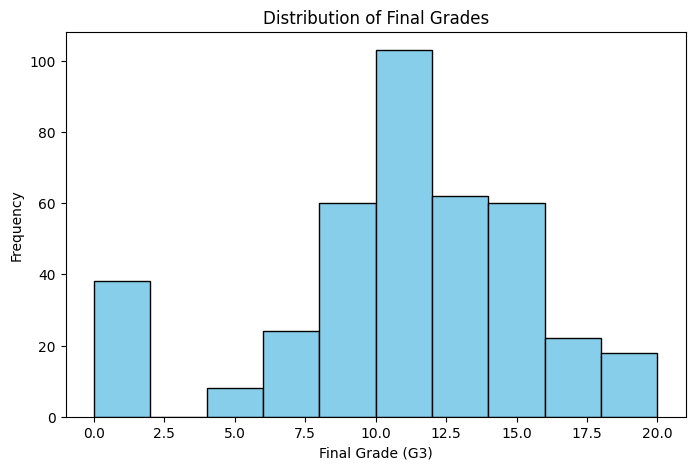

In [19]:
# Histogram of Grades
plt.figure(figsize=(8,5))
plt.hist(df['G3'], bins=10, color='skyblue', edgecolor='black')
plt.title('Distribution of Final Grades')
plt.xlabel('Final Grade (G3)')
plt.ylabel('Frequency')
plt.show()

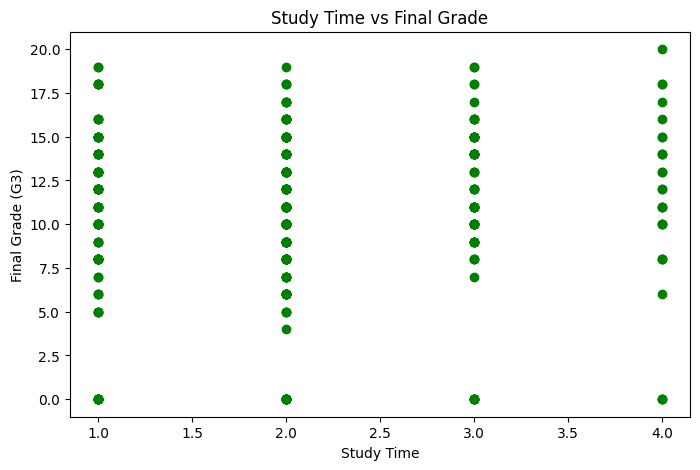

In [20]:
# Scatter Plot: Study Time vs Grade
plt.figure(figsize=(8,5))
plt.scatter(df['studytime'], df['G3'], color='green')
plt.title('Study Time vs Final Grade')
plt.xlabel('Study Time')
plt.ylabel('Final Grade (G3)')
plt.show()

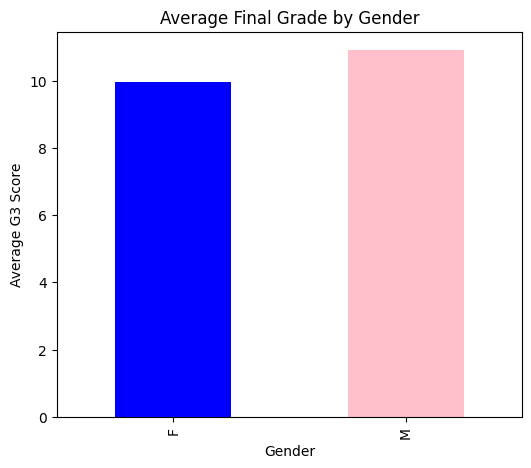

In [21]:
# Bar Chart: Male vs Female Average Score
plt.figure(figsize=(6,5))
gender_performance.plot(kind='bar', color=['blue', 'pink'])
plt.title('Average Final Grade by Gender')
plt.xlabel('Gender')
plt.ylabel('Average G3 Score')
plt.show()

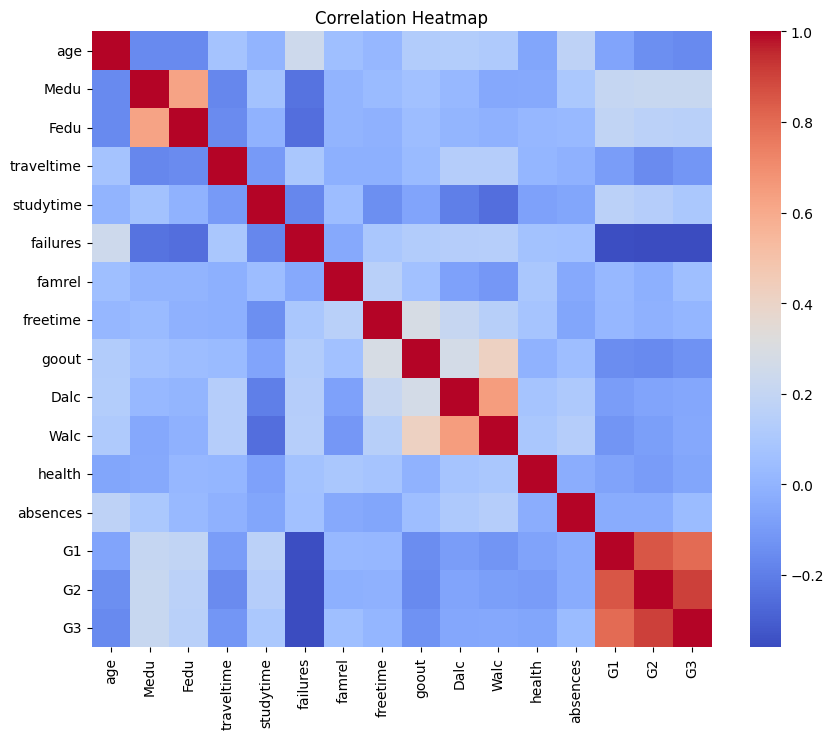

In [22]:
# Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True),
            cmap='coolwarm',
            annot=False)
plt.title('Correlation Heatmap')
plt.show()

# --------------------------
# 5. FINAL SUMMARY
# --------------------------

In [23]:
print("\n========== SUMMARY ==========")
print("Average Final Grade:", round(avg_grade, 2))
print("Students Above 15:", above_15)
print("Study Time Correlation:", round(correlation, 2))
print("Best Performing Gender:", best_gender)


========== SUMMARY ==========
Average Final Grade: 10.42
Students Above 15: 40
Study Time Correlation: 0.1
Best Performing Gender: M
